In [1]:
import numpy as np
import pandas as pd
from matplotlib import pylab as plt
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import cmocean as cmo

metadata_file = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)

computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/FMac/computing/data/antarctica/' #mount path
pth_ismip6hack= mnt_pth + 'ismip6/hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6/hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6/hackathon/ComputedScalarsHelene/'
pth_dils_table = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupBMBtodSLR/data_analysis/tables/'
pth_ms_table = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/tables/'

sec2year = 365.25*24*3600
kg2Gt = 1e-12

In [2]:
def scale_dict(input_dict):
    min_val = min(input_dict.values())
    max_val = max(input_dict.values())
    
    if max_val == min_val:
        scaled_values = {key: 3 for key in input_dict}  # Midpoint of range (1 to 5)
        color_map = cmo.cm.haline
        colors = {key: color_map(0.5) for key in input_dict}  # Midpoint color
        return scaled_values, colors
    
    color_map = cmo.cm.haline
    normalize = plt.Normalize(vmin=min_val, vmax=max_val)
    
    scaled_values = {
        key: 1 + (value - min_val) / (max_val - min_val) * (10 - 1)
        for key, value in input_dict.items()}
    colors = {key: color_map(normalize(value)) for key, value in input_dict.items()}
    
    return scaled_values, colors

### Get all the data

In [3]:
colors = ['#1f77b4','#2ca02c','#9467bd']
colors2 = ['darksalmon','coral','olive']
scatters = ['.','+','^','v']

df_dils = pd.read_csv(f'{pth_dils_table}best_dils_per_model_v3_unitchange_Gtunitfix.csv')
df_ms = pd.read_csv(f'{pth_ms_table}best_ms_method_per_model.csv')

In [4]:
df_dils

,Unnamed: 0,Model,calving,initialisation,resolution,meltonpartial,icefront,dils_AIS,dils_min_AIS,dils_max_AIS,...,dils_max_Ross,dils_FilchnerRonne,dils_min_FilchnerRonne,dils_max_FilchnerRonne,dils_Aurora,dils_min_Aurora,dils_max_Aurora,dils_Wilkes,dils_min_Wilkes,dils_max_Wilkes
0,0,DC_ISSM,2,DA,4km,SG,MH,0.139202,0.084437,0.186464,...,0.289350,0.225896,0.190427,0.305836,0.160476,0.137236,0.194806,0.275010,0.186216,0.365767
1,1,DOE_MALI_4km,2,DA+,4km,FC,RO,0.539856,0.403630,0.651688,...,0.708535,0.459150,0.332870,0.676987,0.521899,0.448875,0.593079,0.654557,0.594721,0.686058
2,2,DOE_MALI_8km_Ant95,2,DA+,8km,FC,RO,0.535333,0.459921,0.633979,...,0.888363,0.561681,0.448808,0.761512,0.662929,0.528583,0.833126,0.755348,0.658566,0.832581
3,3,DOE_MALI_8km_AntMean,2,DA+,8km,FC,RO,0.519709,0.439775,0.609567,...,0.902589,0.527032,0.399591,0.729831,0.597266,0.502343,0.708308,0.742029,0.670840,0.848854
4,4,IGE_ElmerIce,2,DA,1km,no,Fix,0.076694,0.022917,0.107247,...,0.130232,0.118594,0.106446,0.134246,0.060359,-0.006818,0.113457,0.373866,0.357118,0.394378
5,5,ILTS_SICOPOLIS,2,SP+,8km,FC,MH,0.609922,0.499309,0.718761,...,0.713550,0.480342,0.413958,0.576629,0.593752,0.478827,0.718442,0.625559,0.302437,0.832045
6,6,IMAU_UFEMISM1,2,SP+,32km,FC,Fix,2.356588,0.812217,4.025508,...,7.377036,4.085152,0.531605,8.374722,13.615738,-0.391099,32.297789,-0.561217,-2.244870,0.000000
7,7,IMAU_UFEMISM2,2,SP+,32km,FC,Fix,2.611821,1.105948,4.649660,...,5.691460,4.275231,0.715436,9.712004,-33.201393,-92.307697,-0.804593,-0.776168,-3.104670,0.000000
8,8,IMAU_UFEMISM3,2,SP+,16km,FC,Fix,2.146105,1.292535,3.496777,...,3.512557,2.450950,0.802884,5.258994,2.923404,-0.318579,4.864287,-26.794978,-102.295255,0.042116
9,9,IMAU_UFEMISM4,2,SP+,16km,FC,Fix,2.225853,1.305627,3.710895,...,3.242107,5.048371,0.841683,15.436943,3.129304,2.153495,4.345093,-15.467220,-62.414461,1.570448


In [5]:
df_ms

,Unnamed: 0,Model,mean-error,method,parameterization,melt_sensetivity_AIS,melt_sensetivity_intercept_AIS,melt_sensetivity_Amundsen,melt_sensetivity_intercept_Amundsen,melt_sensetivity_Ross,melt_sensetivity_intercept_Ross,melt_sensetivity_FilchnerRonne,melt_sensetivity_intercept_FilchnerRonne,melt_sensetivity_Aurora,melt_sensetivity_intercept_Aurora,melt_sensetivity_Wilkes,melt_sensetivity_intercept_Wilkes
0,0,DC_ISSM,1.126875,df_maxbmb,Quad. Non-local,3.940746,-1.694661,8.640169,-3.372736,3.354130,-1.536894,4.269001,-1.984396,6.983680,-2.124761,6.423657,-3.994535
1,1,DOE_MALI_4km,1.542692,df_maxbmb,Quad. Non-local,7.091286,-4.422678,18.827810,-17.018395,4.042975,-1.908087,5.389555,-2.404711,9.581578,-2.970956,10.618707,-7.781417
2,2,DOE_MALI_8km_Ant95,1.609465,df_maxbmb,Quad. Non-local,10.636001,-8.527297,21.835821,-23.217318,4.302845,-1.895368,6.010999,-2.553659,11.298475,-4.911402,13.488096,-10.237464
3,3,DOE_MALI_8km_AntMean,1.336166,df_maxbmb,Quad. Non-local,6.905944,-3.671605,17.703470,-16.183663,4.345924,-2.012370,6.094617,-2.850230,10.741955,-4.673022,11.403571,-8.562308
4,4,IGE_ElmerIce,1.822429,df_maxbmb,PICO,1.887178,0.270598,2.611416,8.705787,1.570026,-0.379978,1.837577,-1.078901,8.152143,0.464576,7.746371,-0.735873
5,5,ILTS_SICOPOLIS,1.855219,df_maxbmb,Quad. Non-local,9.529746,-7.334161,19.867998,-14.139391,4.215458,-1.940084,5.730758,-2.780314,9.565332,-1.560262,11.426381,-7.366425
6,6,LSCE_GRISLI2,1.479912,df_maxbmb,Quad. Non-local,5.442525,-2.596553,17.034515,-12.135003,3.643000,-1.662566,4.935931,-2.318317,7.970280,-1.027697,8.469353,-4.225666
7,7,LSCE_GRISLI,1.517942,df_maxbmb,Quad. Non-local,5.507551,-2.621882,17.728342,-13.573608,3.606178,-1.647675,5.148203,-2.499429,8.673908,-1.482538,9.330892,-5.637042
8,8,NCAR_CISM1,1.399016,df_maxbmb,Quad. Non-local,3.792347,-1.423690,6.875624,-9.698237,3.831562,-1.801018,4.972992,-2.467405,2.365846,-3.200780,5.339243,-3.602602
9,9,NCAR_CISM2,1.702342,df_maxbmb,Quad. Local,5.509823,-2.209888,11.917042,-12.972440,4.581646,-1.519366,6.870203,-2.637447,7.991848,-2.447761,7.707624,-2.205806


In [6]:
np.mean(np.sort(df_ms['melt_sensetivity_FilchnerRonne'])[-10:])

17.171180475282384

In [7]:
np.mean(np.sort(df_ms['melt_sensetivity_FilchnerRonne'])[:10])

3.1613071088439404

In [8]:
## min, max, median of MS for manuscript discussion
print('MS Amundsen')
print(round(np.min(df_ms['melt_sensetivity_Amundsen']),1))
print(round(np.max(df_ms['melt_sensetivity_Amundsen']),1))
print(round(np.median(df_ms['melt_sensetivity_Amundsen']),1))

print('MS Filchner-Ronne')
print(round(np.min(df_ms['melt_sensetivity_FilchnerRonne']),1))
print(round(np.max(df_ms['melt_sensetivity_FilchnerRonne']),1))
print(round(np.median(df_ms['melt_sensetivity_FilchnerRonne']),1))

MS Amundsen
0.5
21.8
9.9
MS Filchner-Ronne
1.0
17.8
5.3


In [9]:
## min, max, median of MS for manuscript discussion
print('DILS AIS')
print(np.min(df_dils['dils_AIS']))
print(np.max(df_dils['dils_AIS']))
print(np.median(df_dils['dils_AIS']))

DILS AIS
0.0766942580107968
2.6118205882882037
0.5197087086494354


## Plot the main figure

#### Exclude some dodgy models

In [10]:
df_ms_new = df_ms.copy()
df_dils_new = df_dils.copy()
# removekeys = ['VUB_AISMPALEO', 'IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
#              'VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3', 'VUW_PISM1_s4',
#              'VUW_PISM2', 'VUW_PISM2_s1', 'VUW_PISM2_s2', 'VUW_PISM2_s3', 'VUW_PISM2_s4']
removekeys = ['VUB_AISMPALEO', 'VUW_PISM1_s1', 'IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4']
for i,key in enumerate(removekeys):
    df_ms_new = df_ms_new.drop(np.where(df_ms_new.Model.values==key)[0][0]).reset_index(drop=True)
    df_dils_new = df_dils_new.drop(np.where(df_dils_new.Model.values==key)[0][0]).reset_index(drop=True)

#### Get the mean SLR contributions across the experiments at 2300

In [11]:
df_dslr2300 = pd.read_csv('/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/tables/dslc_anom_2300.csv')
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
models = np.unique(df_dslr2300.Model.values)
dslr = {}

for i,mod in enumerate(models):
    dm = df_dslr2300[df_dslr2300.Model == mod]
    dslr[mod] = np.mean(dm['AIS'].values)

dslr_scaled, dslr_colors = scale_dict(dslr.copy())

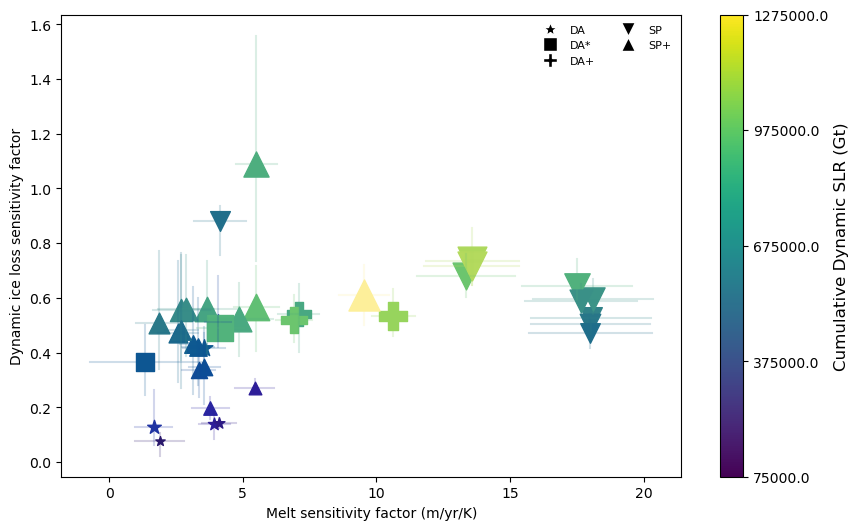

In [12]:
marker_key = 'initialisation'
#marker_key = 'calving'
#marker_key = 'meltonpartial'
#marker_key = 'icefront'
#marker_key = 'resolution'

exclude_pism = 0

# set up the markers
marker_field_u = np.unique(df_dils_new[marker_key])
marker_u = ['*','s','P','v','^','p']
dic_marker = {}
for i,key in enumerate(marker_field_u):
    dic_marker[key]= marker_u[i]
markers = []
marker_nomodel=[]
msk = df_dils_new.Model.values != 'VUW_PISM2_s1'

for key in df_dils_new[marker_key]:
    markers.append(dic_marker[key])

for key in df_dils_new[marker_key][msk]:
    marker_nomodel.append(dic_marker[key])

# set up the colours
color_key = 'parameterization'
color_field_u = np.unique(df_ms_new[color_key])
color_u = ['black', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
dic_color = {}
for i,key in enumerate(color_field_u):
    dic_color[key]= color_u[i]
colors = []
color_nomodel=[]
msk = df_ms_new.Model.values != 'VUW_PISM2_s1'

for key in df_ms_new[color_key]:
    colors.append(dic_color[key])

for key in df_ms_new[color_key][msk]:
    color_nomodel.append(dic_color[key])

# plot the thing
f,ax = plt.subplots(1,1,figsize =(10,6))

xms = df_ms_new['melt_sensetivity_AIS'].values
xr = df_ms_new['mean-error'].values
xl = xms-xr/2
xu = xms+xr/2

ydils = df_dils_new['dils_AIS'].values
yl = df_dils_new['dils_min_AIS'].values
yu = df_dils_new['dils_max_AIS'].values

# x_reshape = xms.reshape(-1, 1)
# model = LinearRegression()
# model.fit(x_reshape, ydils)
# y_pred = model.predict(x_reshape)
# plt.plot(xms, y_pred, label='linregress', zorder=-1, color='gray',linestyle='-')


for i in range(len(xms)):
    mod = df_dils_new.Model.values[i]
    plt.scatter(xms[i], ydils[i], marker=markers[i], color=dslr_colors[mod], s=50*dslr_scaled[mod])
    plt.plot([xms[i],xms[i]], [yl[i],yu[i]], alpha=0.2, color=dslr_colors[mod])
    plt.plot([xl[i],xu[i]], [ydils[i],ydils[i]], alpha=0.2, color=dslr_colors[mod])
    #plt.scatter(xms[i], ydils[i], marker=markers[i], color=colors[i], s=50*dslr_scaled[mod])    
    # if df_dils_new.Model.values[i][:3]=='DOE':
    #     plt.text(xms[i], ydils[i], df_dils_new.Model.values[i])

clabels = np.linspace(round(min(dslr.values()),-3), round(max(dslr.values()),-3), 5)  # Use only a subset of the colormap
cbar = plt.colorbar()
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])  # Specify tick positions
cbar.set_ticklabels(clabels)  # Custom labels
cbar.set_label("Cumulative Dynamic SLR (Gt)", fontsize=12)

mi = len(marker_field_u)
marker_handles = [Line2D([0], [0], marker=marker, color='w', markerfacecolor='k', markersize=10) for marker in marker_u[:mi]]
#ci = len(color_field_u)
#color_handles = [Line2D([0], [0], color=color, lw=2) for color in color_u[:ci]]
#custom_handles = color_handles + marker_handles
custom_handles = marker_handles
custom_labels = list(marker_field_u)
#custom_labels = list(color_field_u) + list(marker_field_u)
ax.legend(handles=custom_handles, labels=custom_labels,
         loc='upper right', bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize = 8)

ax.set_xlabel('Melt sensitivity factor (m/yr/K)')
ax.set_ylabel('Dynamic ice loss sensitivity factor')

if exclude_pism == 1:
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/ms_dils_AIS_{marker_key}_novuwpism_Gtunitfix.pdf', bbox_inches='tight')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/ms_dils_AIS_{marker_key}_novuwpism_Gtunitfix.jpeg', bbox_inches='tight')    
else:
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/ms_dils_AIS_{marker_key}_Gtunitfix.pdf', bbox_inches='tight')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/ms_dils_AIS_{marker_key}_Gtunitfix.jpeg', bbox_inches='tight')

In [16]:
round(min(dslr.values()),-3)

75000.0

In [17]:
max(dslr.values())

1274802.5625

In [18]:
min(dslr.values())

74931.2744140625

In [17]:
#output Gt values in m SLR
A = 361*10**6 *(1000)**2;
Gt2mSLE =10**12/(1000 *A)
max_dslr = max(dslr.values())*Gt2mSLE
min_dslr = min(dslr.values())*Gt2mSLE

### get MS and DS data as columns for table 2

In [18]:
csv_output_dils = (df_dils[['dils_AIS', 'dils_min_AIS', 'dils_max_AIS']]).to_csv('table2_dsfactors_Gtunitfix.csv',index=False, header=True,float_format='%.1f')

In [27]:
(df_dils[['dils_AIS']].values.max())

2.6118205882882037

In [28]:
df_dils[['dils_AIS']].values.min()

0.0766942580107968

In [30]:
np.median(df_dils[['dils_AIS']].values)

0.5197087086494354